# TokaLab Notebook

## Introduction
This notebook demonstrates how to use TokaLab through the following steps:

1. Initialize VirtualLab (this step is important to correctly set all required paths).
2. Upload the machine configuration.
3. Upload the scenario configuration and modify specific parameters if needed.
4. Prepare the geometry (grid, walls, etc.).
5. Solve the Grad–Shafranov equilibrium for the specified parameters.
6. Evaluate diagnostic measurements based on the computed equilibrium.
7. Perform multi-fidelity calculations of the polarimeter signal (Type-1 vs. Stokes simulation, cold vs. hot plasma assumptions).

## Initialize VirtualLab

TokaLab is organized into several modules, each contained in a different folder.  
To prepare the environment, you can use `VirtualLab_init`, which automatically adds all required folders to the path and checks that the necessary packages are available.

In [2]:
from VirtualLab_init import *

new added path : c:\Users\ricca\OneDrive\PJ - 02 - TOKALAB_fusion\01 - github repositories\VirtualLab\VirtualLab_Python\examples
new added path : c:\Users\ricca\OneDrive\PJ - 02 - TOKALAB_fusion\01 - github repositories\VirtualLab\VirtualLab_Python\SimPla_Python
new added path : c:\Users\ricca\OneDrive\PJ - 02 - TOKALAB_fusion\01 - github repositories\VirtualLab\VirtualLab_Python\SimPla_Python\functions
new added path : c:\Users\ricca\OneDrive\PJ - 02 - TOKALAB_fusion\01 - github repositories\VirtualLab\VirtualLab_Python\SimPla_Python\tokamaks
new added path : c:\Users\ricca\OneDrive\PJ - 02 - TOKALAB_fusion\01 - github repositories\VirtualLab\VirtualLab_Python\SimPla_Python\tokamaks\equilibrium
new added path : c:\Users\ricca\OneDrive\PJ - 02 - TOKALAB_fusion\01 - github repositories\VirtualLab\VirtualLab_Python\SimPla_Python\tokamaks\geometry
new added path : c:\Users\ricca\OneDrive\PJ - 02 - TOKALAB_fusion\01 - github repositories\VirtualLab\VirtualLab_Python\SimPla_Python\tokamaks\

## Tokamak (from SimPla)

The **tokamak** object contains the functions required to initialize the environment and load the scenario.

First, we initialize the **tokamak** object (hereafter referred to as **tok**).

We then apply the following functions:
- `machine_upload`
- `scenario_upload`
- `kinetic_upload`

In [3]:
from tokamak import tokamak # import object

tok = tokamak() # tokamak object initialisation

tok.machine_upload("TokaLab") # upload machine data to the tokamak object
tok.scenario_upload() # upload standard scenario data to the tokamak object
tok.kinetic_upload() # upload kinetic data to the tokamak object

TokaLab


## Geometry (from SimPla)

The **geometry** object imports the geometry information associated with the **tokamak** configuration (geometry limits, walls, etc.), constructs the computational **grid**, and evaluates additional quantities required by different codes (e.g., the mask identifying which elements are inside or outside the wall).

In [4]:
from geometry import geometry # import geometry object

geo = geometry() # geometry object initialisation
geo.import_geometry(tok) # import geometry from the tokamak object
geo.build_geometry() # build geometry (create grid)
geo.inside_wall() # find grid points inside the wall (mask)

## Equilibrium (from SimPla)

The **equilibrium** object allows the reconstruction of a tokamak plasma equilibrium under specified conditions and hyperparameters.

At present, **VirtualLab_python** only includes a fixed-boundary solver.

### Fixed-Boundary Equilibrium Solver

The fixed-boundary equilibrium solver computes the solution of the Grad–Shafranov (GS) equation by imposing the following conditions:

- The flux coordinate ψ is set to zero at the **target separatrix**.
- The toroidal current follows a prescribed functional form associated with the **toroidal current profile**.

In [5]:
from equilibrium import equilibrium # import equilibrium object

equi = equilibrium() # equilibrium object initialisation
equi.import_configuration(geo, tok.config) # import equilibrium configuration from the tokamak object and geometry object
equi.import_classes() # import equilibrium classes 

### Target separatrix
The target separatrix, computer by the function separatrix.build_separatrix* is based on analytical function proposed in [Jean, J. (2011) HELIOS: a zero-dimensional tool for next step and reactor studies. Fusion Science and Technology, 59(2), 308-349.]( https://doi.org/10.13182/FST11-A11650). This formulation allows to generate different kind of target separatrix by changing many hyperparameters such as the size, traingluarites, elongations, etc.

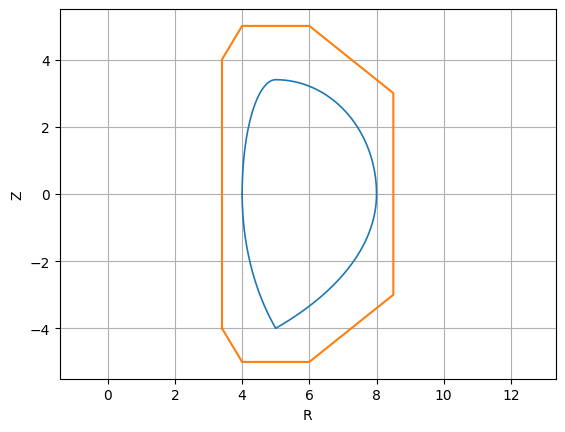

In [6]:
equi.separatrix.build_separatrix(equi.config.separatrix,equi.geo) # build target separatrix 
equi.plot_separatrix() # plot target separatrix

The above separatrix is the standard target separatrix used for TokaLab. It is possible to change any parameter to have a decide your specific separatrix. 

Configuration for a double null: 

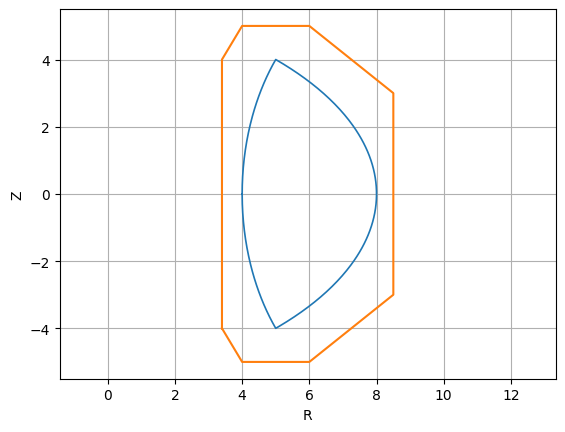

In [7]:
from math import pi

equi.config.separatrix.a = 2
equi.config.separatrix.R0 = 6
equi.config.separatrix.Z0 = 0
equi.config.separatrix.k1 = 2
equi.config.separatrix.k2 = 2
equi.config.separatrix.d1 = 0.5
equi.config.separatrix.d2 = 0.5
equi.config.separatrix.gamma_n_1 = pi/3
equi.config.separatrix.gamma_n_2 = pi/3
equi.config.separatrix.gamma_p_1 = pi/6
equi.config.separatrix.gamma_p_2 = pi/6

equi.separatrix.build_separatrix(equi.config.separatrix,equi.geo) # build target separatrix 
equi.plot_separatrix() # plot target separatrix


Configuration for a negative triangularity: 

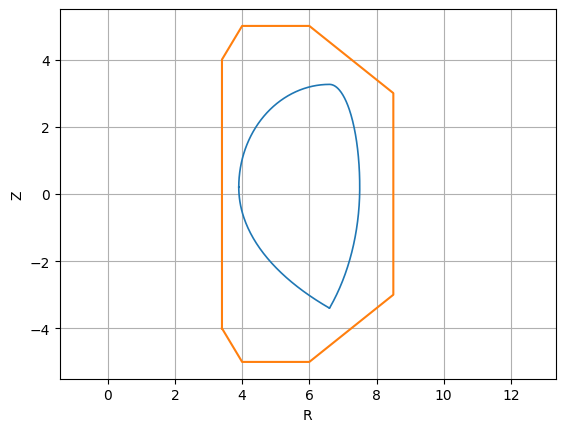

In [8]:
equi.config.separatrix.a = 1.8
equi.config.separatrix.R0 = 5.7
equi.config.separatrix.Z0 = 0.2
equi.config.separatrix.k1 = 1.7
equi.config.separatrix.k2 = 2
equi.config.separatrix.d1 = -0.5
equi.config.separatrix.d2 = -0.5
equi.config.separatrix.gamma_n_1 = 0
equi.config.separatrix.gamma_n_2 = pi/6
equi.config.separatrix.gamma_p_1 = 0
equi.config.separatrix.gamma_p_2 = pi/3

equi.separatrix.build_separatrix(equi.config.separatrix,equi.geo) # build target separatrix 
equi.plot_separatrix() # plot target separatrix

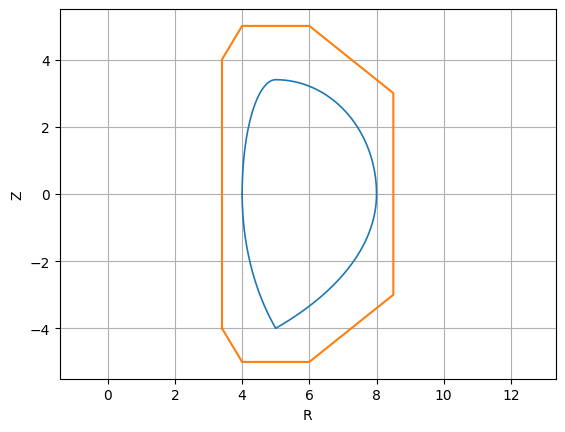

In [9]:
# Use this block to choose your separatrix
equi.config.separatrix.a = 2
equi.config.separatrix.R0 = 6
equi.config.separatrix.Z0 = 0
equi.config.separatrix.k1 = 1.7
equi.config.separatrix.k2 = 2
equi.config.separatrix.d1 = 0.5
equi.config.separatrix.d2 = 0.5
equi.config.separatrix.gamma_n_1 = 0
equi.config.separatrix.gamma_n_2 = pi/3
equi.config.separatrix.gamma_p_1 = 0
equi.config.separatrix.gamma_p_2 = pi/6

equi.separatrix.build_separatrix(equi.config.separatrix,equi.geo) # build target separatrix 
equi.plot_separatrix() # plot target separatrix

### Toroidal Current Density Profile

The toroidal current profile is based on an analytical function that has been used in several studies. As a reference, we adopt the formulation presented in  
[Coleman, M., & McIntosh, S. (2020). *The design and optimisation of tokamak poloidal field systems in the BLUEPRINT framework*. Fusion Engineering and Design, 154, 111544](https://doi.org/10.1016/j.fusengdes.2020.111544).

Similarly to the target separatrix, a standard scenario is automatically loaded. However, all parameters can be modified through `equi.config.toroidal_current`:

In [10]:
equi.config.toroidal_current.Bt = 5 # toroidal magnetic field in Tesla
equi.config.toroidal_current.Ip = -12e6 # plasma current in Amperes
equi.config.toroidal_current.alpha_1 = 2 # parameter 1 of the toroidal current profile 
equi.config.toroidal_current.alpha_2 = 2 # parameter 2 of the toroidal current profile
equi.config.toroidal_current.beta_0 = 0.5 # parameter 3 of the toroidal current profile used to define pressure gradient

### Grad–Shafranov Solver

Once all hyperparameters have been defined, the GS solver can be used to compute the magnetic flux on the poloidal cross-section. The GS solver hyperparameters (e.g., tolerance, number of iterations) can be specified before running the solver.

After solving the Grad–Shafranov equation, two functions are applied to evaluate the relevant fields:

- **equi_pp**, used to compute MHD-related quantities (magnetic fields, current density, pressure).
- **compute_profiles**, used to evaluate kinetic profiles from the equilibrium (these profiles are based on simple analytical relations between kinetic quantities and the magnetic flux).

1
2
3
4
5
6
7
8
9
10


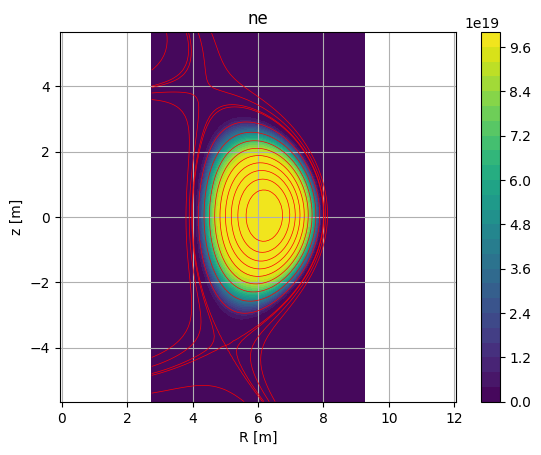

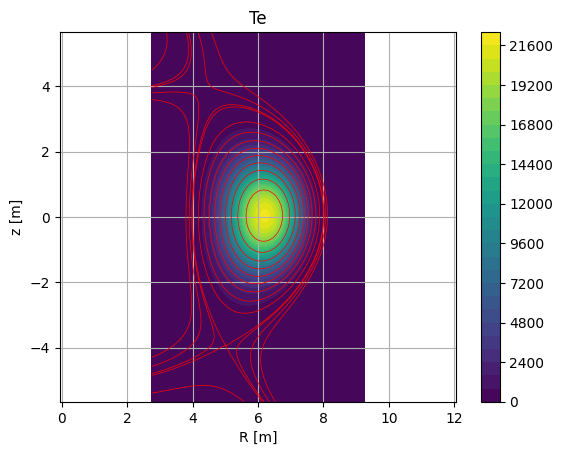

In [11]:
equi.config.GSsolver.abs_tol = 1e-6 # absolute tolerance for the Grad-Shafranov solver
equi.config.GSsolver.maxIter = 10 # maximum number of iterations for the Grad-Shafranov solver

equi.solve_equilibrium_dimless() # solve the equilibrium in dimensionless form 

equi.equi_pp() # MHD related quantities

equi.compute_profiles() # kinetic fields given analytical profiles (y vs psi)

equi.plot_fields('ne') # plot electron density field 
equi.plot_fields('Te') # plot electron temperature field 

## Diagnostics (from SynDiag)

Once the plasma fields have been simulated, various diagnostics can be implemented to simulate measurements.

The following diagnostics have been implemented:

- Pick-Up Coils
- Flux Loops
- Saddle Coils
- Thomson Scattering
- Interferometer
- Polarimeter

Each diagnostic is represented by an object with three main functions:

- `upload` – used to load the standard configuration.
- `measure` – computes the signal based on the equilibrium solution.
- `plot` – visualizes the results.

Similarly to the equilibrium, any hyperparameter can be modified after uploading the configuration and before performing the measurement.

### Pick Up Coils

Pick Up coils allows to measure the local magnetic field along a specific direction. 

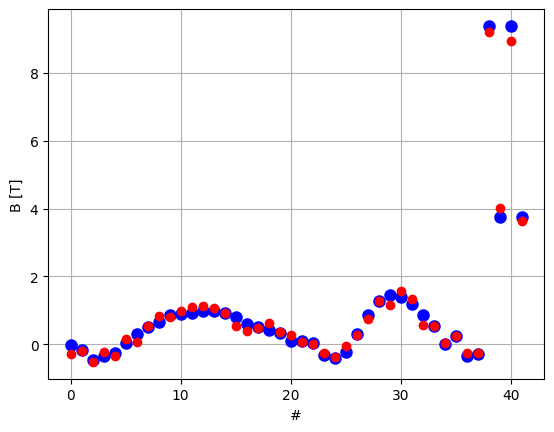

In [12]:
from Diag_PickUpCoils import Diag_PickUpCoils

PickUp = Diag_PickUpCoils() # PickUp object initialisation
PickUp.upload() # upload diagnostic data to the PickUp object 
PickUp.measure(equi) # compute the diagnostic signals given the equilibrium solution
PickUp.plot_StandAlone() # plot the diagnostic signals

### Flux Loops




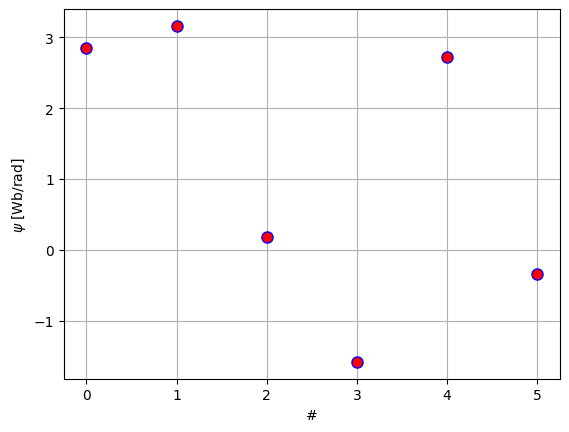

In [13]:
from Diag_FluxLoops import Diag_FluxLoops

FluxLoops = Diag_FluxLoops() # FluxLoops object initialisation
FluxLoops.upload() # upload diagnostic data to the FluxLoops object
FluxLoops.measure(equi) # compute the diagnostic signals given the equilibrium solution
FluxLoops.plot_StandAlone() # plot the diagnostic signals


### Saddle Coils



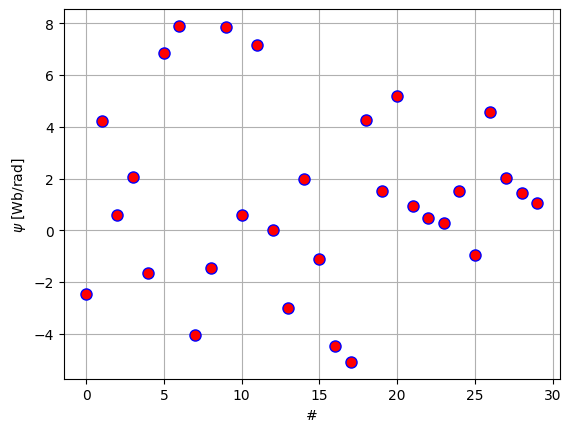

In [14]:
from Diag_SaddleCoils import Diag_SaddleCoils

SaddleCoils = Diag_SaddleCoils() # SaddleCoils object initialisation
SaddleCoils.upload() #  upload diagnostic data to the SaddleCoils object
SaddleCoils.measure(equi) # compute the diagnostic signals given the equilibrium solution
SaddleCoils.plot_StandAlone() # plot the diagnostic signals

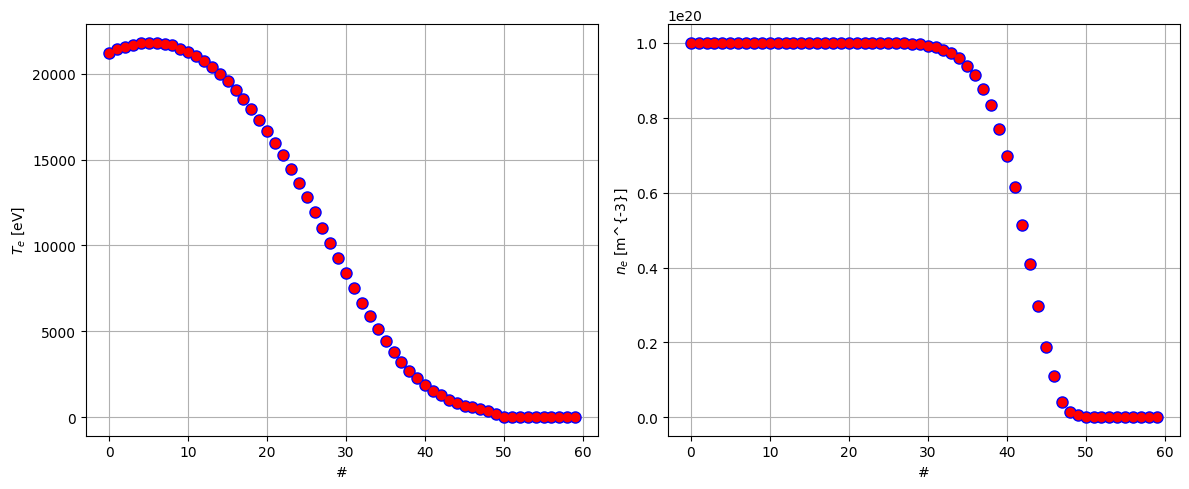

In [15]:
from Diag_ThomsonScattering import Diag_ThomsonScattering

TS = Diag_ThomsonScattering() # ThomsonScattering object initialisation
TS.upload() # upload diagnostic data to the ThomsonScattering object
TS.measure(equi) # compute the diagnostic signals given the equilibrium solution
TS.plot_StandAlone() # plot the diagnostic signals


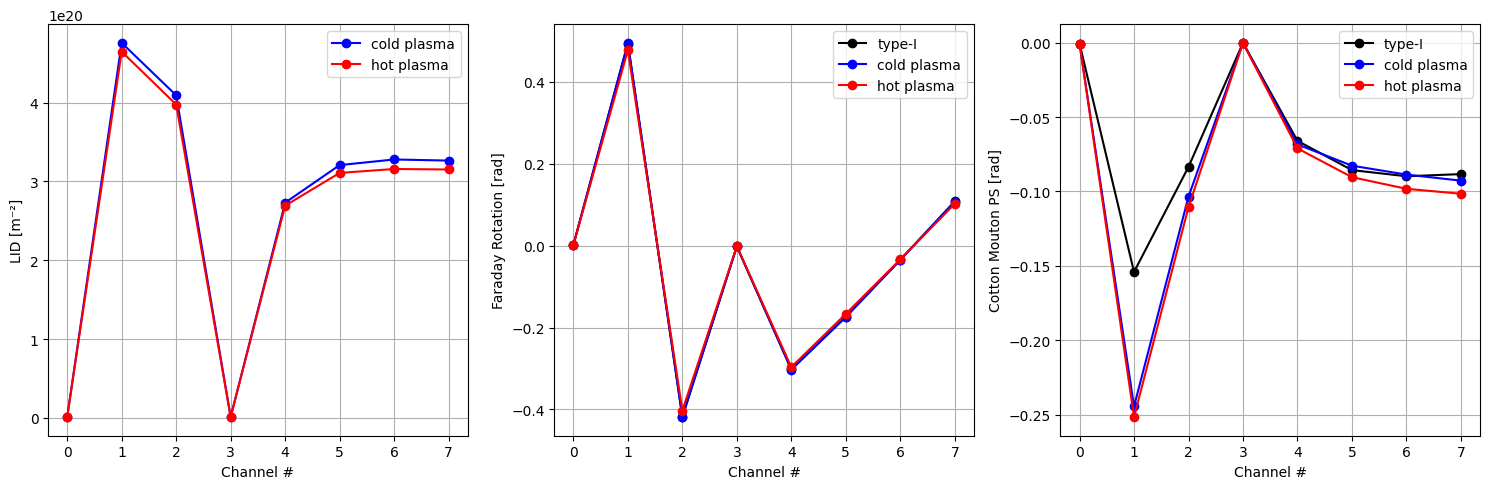

In [16]:
from Diag_InterferometerPolarimeter import Diag_InterferometerPolarimeter

IP = Diag_InterferometerPolarimeter() # InterferometerPolarimeter object initialisation
IP.upload() # upload diagnostic data to the InterferometerPolarimeter object
IP.measure(equi) # compute the diagnostic signals given the equilibrium solution
IP.plot_StandAlone() # plot the diagnostic signals

## Multi-Fidelity Physics Approach

Each problem can be solved at different levels of fidelity. As an example, consider the polarimeter diagnostic, which can be simulated in multiple ways. Here, we use both the so-called **Type-I approximation** and the **full-Stokes model**, each under **cold** and **hot plasma** assumptions. 

Thus, the models considered are:

- Type-I calculation with cold plasma
- Type-I calculation with hot plasma
- Full-Stokes calculation with cold plasma
- Full-Stokes calculation with hot plasma

Using TokaLab, one can easily explore how the models work, how to perform simulations, and evaluate the validity of different approximations (useful for physics studies), as well as identify which parameters have the greatest impact (important for design).

Below, we present a code example that simulates the plasma under different laser wavelengths.

### Laser wavelength effect

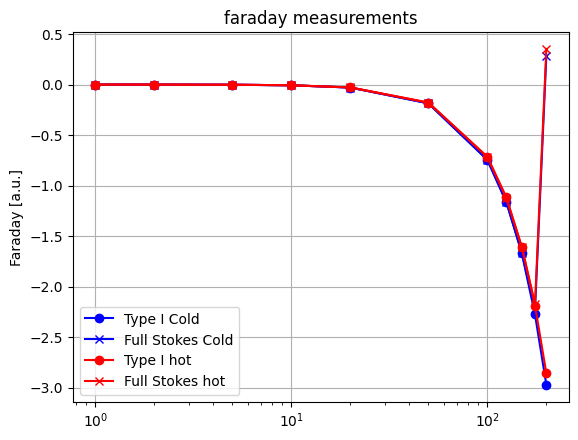

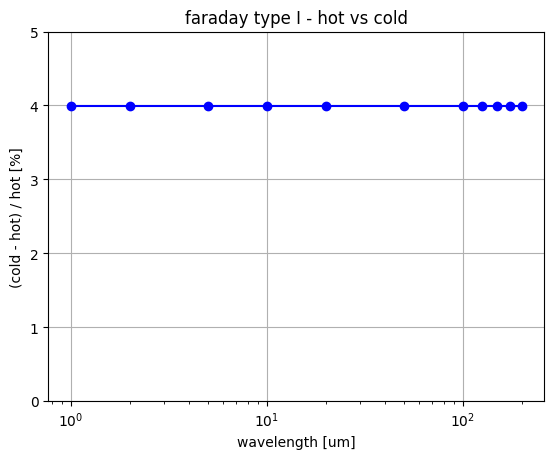

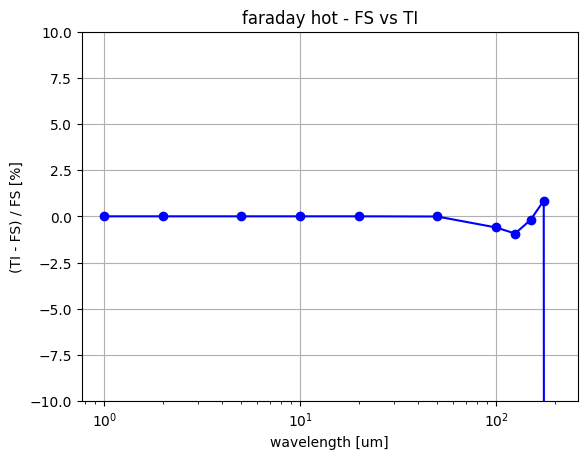

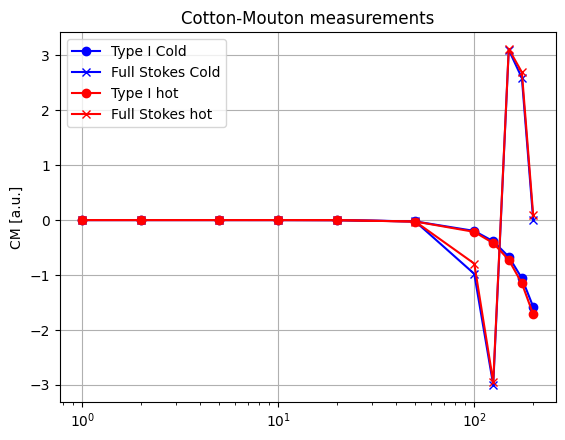

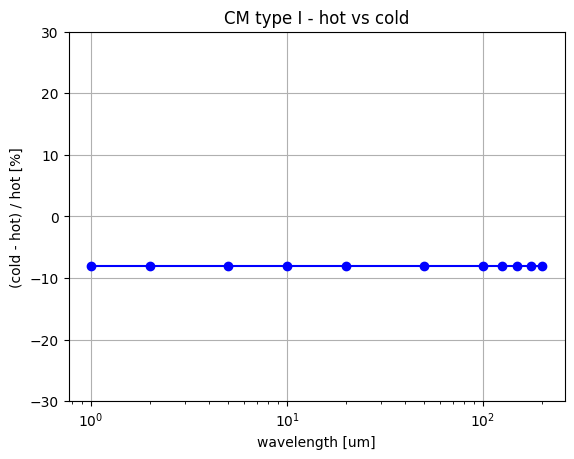

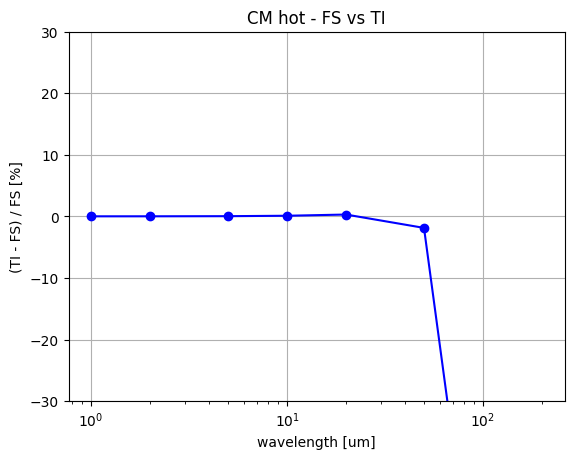

In [17]:
import numpy as np
import matplotlib.pyplot as plt

ch = 3
wavelengths = [1e-6, 2e-6, 5e-6, 10e-6, 20e-6, 50e-6, 100e-6, 125e-6, 150e-6, 175e-6, 200e-6]
wavelengths = np.array(wavelengths) # convert to numpy array for plotting

far_TI_cold = np.array([])
far_TI_hot = np.array([])
far_FS_cold = np.array([])
far_FS_hot = np.array([])

CM_TI_cold = np.array([])
CM_TI_hot = np.array([])
CM_FS_cold = np.array([])
CM_FS_hot = np.array([])


for j in wavelengths:
    IP.config["lambda"] = j
    IP.measure(equi)

    far_TI_cold = np.append(far_TI_cold, IP.FARc_typeI[ch-1])
    far_TI_hot = np.append(far_TI_hot, IP.FARh_typeI[ch-1])
    far_FS_cold = np.append(far_FS_cold, IP.FARc[ch-1])
    far_FS_hot = np.append(far_FS_hot, IP.FARh[ch-1])

    CM_TI_cold = np.append(CM_TI_cold, IP.CMc_typeI[ch-1])
    CM_TI_hot = np.append(CM_TI_hot, IP.CMh_typeI[ch-1])
    CM_FS_cold = np.append(CM_FS_cold, IP.CMc[ch-1])
    CM_FS_hot = np.append(CM_FS_hot, IP.CMh[ch-1])




wavelengths = wavelengths * 1e6 # convert to microns for plotting

plt.figure()
plt.plot(wavelengths, far_TI_cold, marker='o',color='blue', label='Type I Cold')
plt.plot(wavelengths, far_FS_cold, marker='x',color='blue', label='Full Stokes Cold')
plt.plot(wavelengths, far_TI_hot, marker='o',color='red', label='Type I hot')
plt.plot(wavelengths, far_FS_hot, marker='x',color='red', label='Full Stokes hot')
plt.legend()
plt.ylabel("Faraday [a.u.]")
plt.xscale('log')
plt.title("faraday measurements")
plt.grid()

plt.figure()
plt.plot(wavelengths, (far_TI_cold-far_TI_hot)/far_TI_hot*100, marker='o',color='blue')
plt.ylabel("(cold - hot) / hot [%]")
plt.xlabel("wavelength [um]")
plt.title("faraday type I - hot vs cold")
plt.xscale('log')
plt.yscale('linear')
plt.ylim(0, 5)
plt.grid()

plt.figure()
plt.plot(wavelengths, (far_TI_hot-far_FS_hot)/far_FS_hot*100, marker='o',color='blue', label='Type I Cold')
plt.xlabel("wavelength [um]")
plt.ylabel("(TI - FS) / FS [%]")
plt.title("faraday hot - FS vs TI")
plt.xscale('log')
plt.yscale('linear')
plt.ylim(-10, 10)
plt.grid()

plt.figure()
plt.plot(wavelengths, CM_TI_cold, marker='o',color='blue', label='Type I Cold')
plt.plot(wavelengths, CM_FS_cold, marker='x',color='blue', label='Full Stokes Cold')
plt.plot(wavelengths, CM_TI_hot, marker='o',color='red', label='Type I hot')
plt.plot(wavelengths, CM_FS_hot, marker='x',color='red', label='Full Stokes hot')
plt.legend()
plt.ylabel("CM [a.u.]")
plt.xscale('log')
plt.title("Cotton-Mouton measurements")
plt.grid()

plt.figure()
plt.plot(wavelengths, (CM_TI_cold-CM_TI_hot)/CM_TI_hot*100, marker='o',color='blue')
plt.ylabel("(cold - hot) / hot [%]")
plt.xlabel("wavelength [um]")
plt.title("CM type I - hot vs cold")
plt.xscale('log')
plt.yscale('linear')
plt.ylim(-30, 30)
plt.grid()

plt.figure()
plt.plot(wavelengths, (CM_TI_hot-CM_FS_hot)/CM_FS_hot*100, marker='o',color='blue', label='Type I Cold')
plt.ylabel("(TI - FS) / FS [%]")
plt.xlabel("wavelength [um]")
plt.title("CM hot - FS vs TI")
plt.xscale('log')
plt.yscale('linear')
plt.ylim(-30, 30)
plt.grid()




### Temperature effect


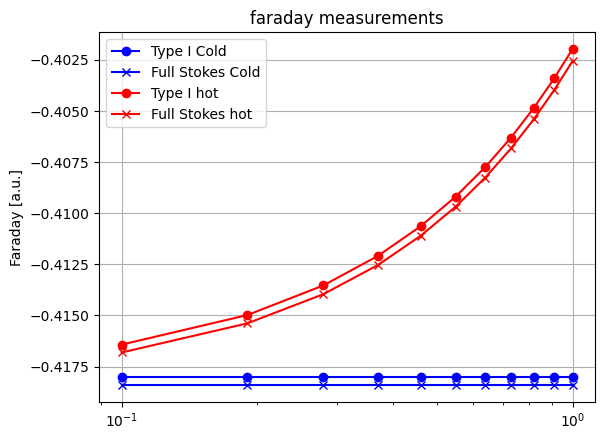

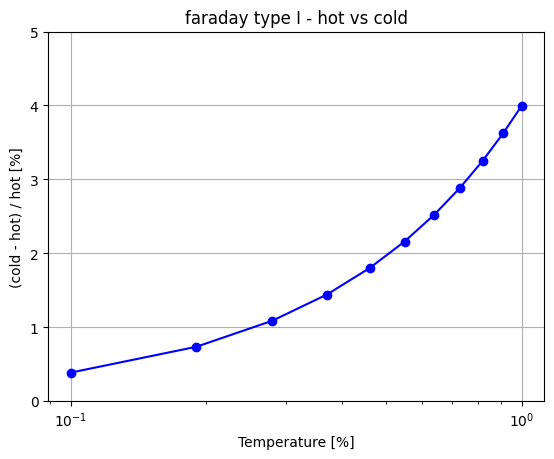

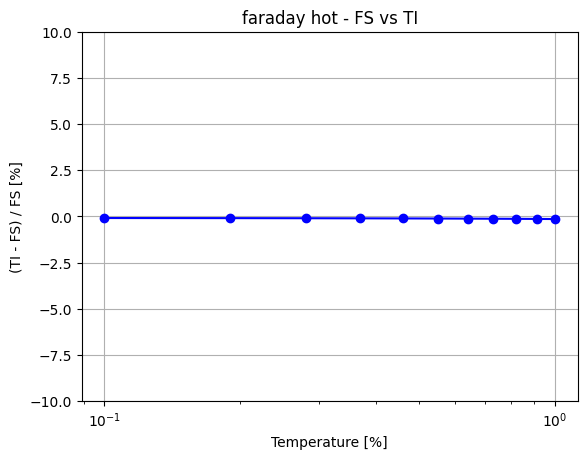

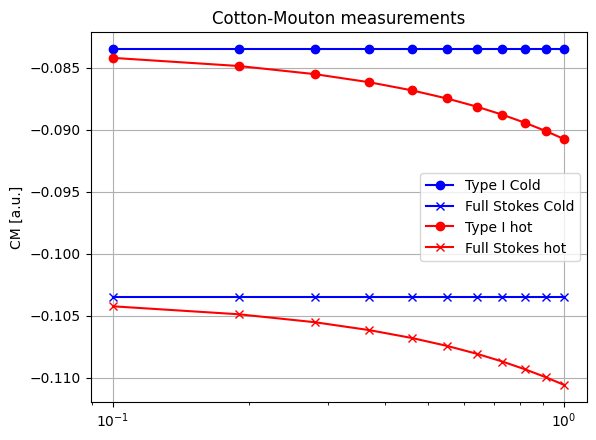

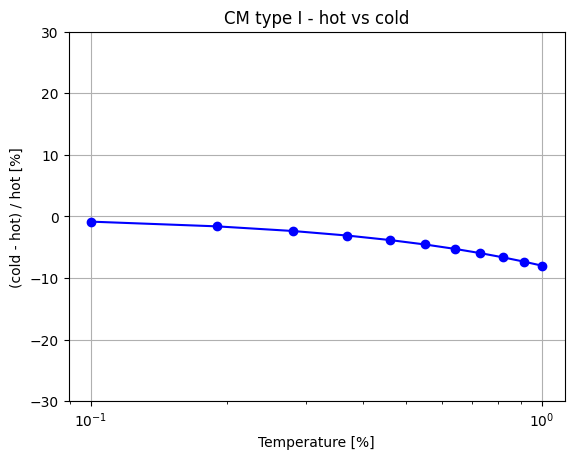

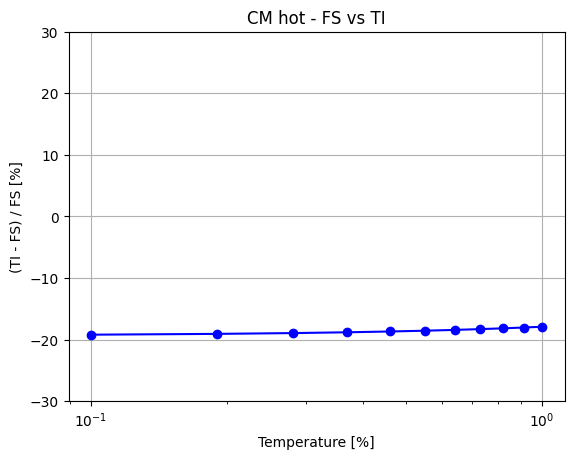

In [18]:
import numpy as np
import matplotlib.pyplot as plt

IP.config["lambda"] = 75e-6 

Temp_perc = np.linspace(0.1, 1, 11) # temperature percentage from 0% to 100% in 10% steps

far_TI_cold = np.array([])
far_TI_hot = np.array([])
far_FS_cold = np.array([])
far_FS_hot = np.array([])

CM_TI_cold = np.array([])
CM_TI_hot = np.array([])
CM_FS_cold = np.array([])
CM_FS_hot = np.array([])

Te = equi.Te


for j in Temp_perc:
    equi.Te = Te * j
    IP.measure(equi)

    far_TI_cold = np.append(far_TI_cold, IP.FARc_typeI[ch-1])
    far_TI_hot = np.append(far_TI_hot, IP.FARh_typeI[ch-1])
    far_FS_cold = np.append(far_FS_cold, IP.FARc[ch-1])
    far_FS_hot = np.append(far_FS_hot, IP.FARh[ch-1])

    CM_TI_cold = np.append(CM_TI_cold, IP.CMc_typeI[ch-1])
    CM_TI_hot = np.append(CM_TI_hot, IP.CMh_typeI[ch-1])
    CM_FS_cold = np.append(CM_FS_cold, IP.CMc[ch-1])
    CM_FS_hot = np.append(CM_FS_hot, IP.CMh[ch-1])

plt.figure()
plt.plot(Temp_perc, far_TI_cold, marker='o',color='blue', label='Type I Cold')
plt.plot(Temp_perc, far_FS_cold, marker='x',color='blue', label='Full Stokes Cold')
plt.plot(Temp_perc, far_TI_hot, marker='o',color='red', label='Type I hot')
plt.plot(Temp_perc, far_FS_hot, marker='x',color='red', label='Full Stokes hot')
plt.legend()
plt.ylabel("Faraday [a.u.]")
plt.xscale('log')
plt.title("faraday measurements")
plt.grid()

plt.figure()
plt.plot(Temp_perc, (far_TI_cold-far_TI_hot)/far_TI_hot*100, marker='o',color='blue')
plt.ylabel("(cold - hot) / hot [%]")
plt.xlabel("Temperature [%]")
plt.title("faraday type I - hot vs cold")
plt.xscale('log')
plt.yscale('linear')
plt.ylim(0, 5)
plt.grid()

plt.figure()
plt.plot(Temp_perc, (far_TI_hot-far_FS_hot)/far_FS_hot*100, marker='o',color='blue', label='Type I Cold')
plt.xlabel("Temperature [%]")
plt.ylabel("(TI - FS) / FS [%]")
plt.title("faraday hot - FS vs TI")
plt.xscale('log')
plt.yscale('linear')
plt.ylim(-10, 10)
plt.grid()

plt.figure()
plt.plot(Temp_perc, CM_TI_cold, marker='o',color='blue', label='Type I Cold')
plt.plot(Temp_perc, CM_FS_cold, marker='x',color='blue', label='Full Stokes Cold')
plt.plot(Temp_perc, CM_TI_hot, marker='o',color='red', label='Type I hot')
plt.plot(Temp_perc, CM_FS_hot, marker='x',color='red', label='Full Stokes hot')
plt.legend()
plt.ylabel("CM [a.u.]")
plt.xscale('log')
plt.title("Cotton-Mouton measurements")
plt.grid()

plt.figure()
plt.plot(Temp_perc, (CM_TI_cold-CM_TI_hot)/CM_TI_hot*100, marker='o',color='blue')
plt.ylabel("(cold - hot) / hot [%]")
plt.xlabel("Temperature [%]")
plt.title("CM type I - hot vs cold")
plt.xscale('log')
plt.yscale('linear')
plt.ylim(-30, 30)
plt.grid()

plt.figure()
plt.plot(Temp_perc, (CM_TI_hot-CM_FS_hot)/CM_FS_hot*100, marker='o',color='blue', label='Type I Cold')
plt.ylabel("(TI - FS) / FS [%]")
plt.xlabel("Temperature [%]")
plt.title("CM hot - FS vs TI")
plt.xscale('log')
plt.yscale('linear')
plt.ylim(-30, 30)
plt.grid()